# Interpretacja modeli (cech)

<div style="display: flex; justify-content: center;">
<img src=".//Images//A_traditional_Boston-style_single-family_house 1.png" alt="Boston" width="200" height="120" style="margin: 10px;"/>
<img src=".//Images//A_traditional_Boston-style_single-family_house 2.png" alt="Boston" width="200" height="120" style="margin: 10px;"/>
<img src=".//Images//A_traditional_Boston-style_single-family_house 3.png" alt="Boston" width="200" height="120" style="margin: 10px;"/>
<img src=".//Images//A_traditional_Boston-style_single-family_house 4.png" alt="Boston" width="200" height="120" style="margin: 10px;"/>
</div>

Interpretacja modeli uczenia maszynowego jest kluczowa dla zrozumienia, w jaki sposób algorytmy podejmują decyzje, co jest istotne zarówno dla poprawy modeli, jak i dla zwiększenia ich przejrzystości w stosunku do użytkowników końcowych. Techniki takie jak **LIME** (Local Interpretable Model-agnostic Explanations) czy **SHAP** (SHapley Additive exPlanations) umożliwiają analizę wpływu poszczególnych cech na predykcje modelu, co pomaga w identyfikacji wzorców i potencjalnych błędów. Stosowanie tych metod może znacząco przyczynić się do budowania zaufania i zrozumienia w procesie wykorzystania modeli uczenia maszynowego w praktycznych zastosowaniach.

## Biblioteki

In [ ]:
import time
import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

## Dane
Jako dane wykorzystamy ceny nieruchomości **Boston Housing**. Zbiór ten został utworzony w roku 1978 na podstawie informacji zebranych przez U.S. Census Service, dotyczących budownictwa mieszkaniowego w rejonie Bostonu w stanie Massachusetts.

Dane można pobrać z Kaggle albo wpisując w Google: „boston dataset”.

Zbiór składa się z 13 cech wejściowych oraz zmiennej docelowej **MEDV**:

* **CRIM** – wskaźnik przestępczości na mieszkańca w danej miejscowości
* **ZN** – udział gruntów mieszkaniowych przeznaczonych pod działki większe niż 25 000 stóp kwadratowych
* **INDUS** – udział akrów terenów biznesowych niezwiązanych z handlem detalicznym w danej miejscowości
* **CHAS** – zmienna zero-jedynkowa (1, jeśli obszar graniczy z rzeką Charles; 0 w przeciwnym razie)
* **NOX** – stężenie tlenków azotu (na 10 milionów części), w zbiorze pełni rolę przybliżenia jakości powietrza,
* **RM** – średnia liczba pokoi na mieszkanie
* **AGE** – udział mieszkań zajmowanych przez właścicieli, zbudowanych przed 1940 r.
* **DIS** – ważone odległości do pięciu bostońskich centrów zatrudnienia
* **RAD** – indeks dostępności do głównych tras wylotowych prowadzących promieniście do i z Bostonu
* **TAX** – pełna stawka podatku od nieruchomości na 10 000 USD
* **PTRATIO** – stosunek liczby uczniów do nauczycieli w danej miejscowości
* **B** – 1000(Bk – 0,63)^2, gdzie Bk oznacza udział ludności czarnej w danej miejscowości
* **LSTAT** – procent populacji o niższym statusie społeczno-ekonomicznym
* **MEDV** – mediana wartości domów zajmowanych przez właścicieli, w tysiącach dolarów

*Cecha B jest dziś uznawana za etycznie problematyczną, ponieważ odnosi się do kategorii rasowej.*

In [2]:
# Wczytanie danych
data_path = ".\\data\\housing.csv"
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
housing_data = pd.read_csv(data_path, header=None, delimiter=r"\s+", names=column_names)
housing_data.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7


Narysujmy kilka przykładowych wykresów by odrobinkę rozpoznać dane. Zacznijmy od wykresów pudełkowych:

In [3]:
df = housing_data.copy()

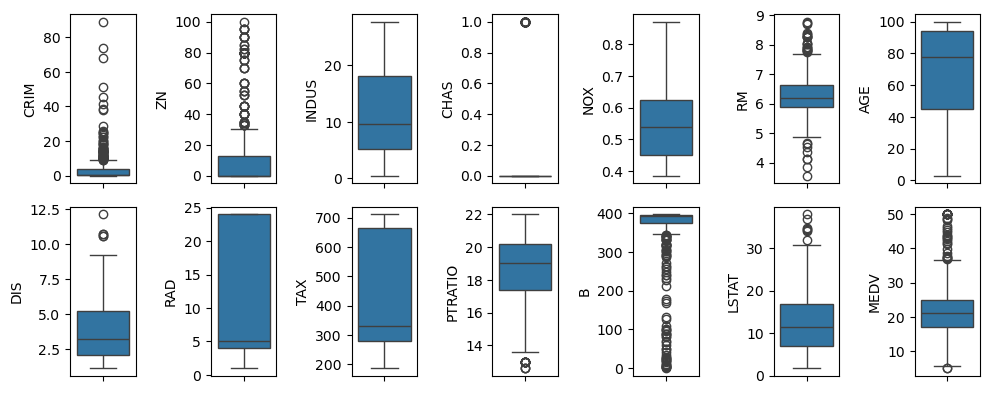

In [4]:
fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(10, 4))
index = 0
axs = axs.flatten()
for k,v in df.items():
    sns.boxplot(y=k, data=df, ax=axs[index])
    index = index + 1
plt.tight_layout()

Od razu można zauważyć, które kolumny mają wartości odstające. Spójrzmy w podobny prosty sposób jeszcze na wykresy gęstości (rozkłady):

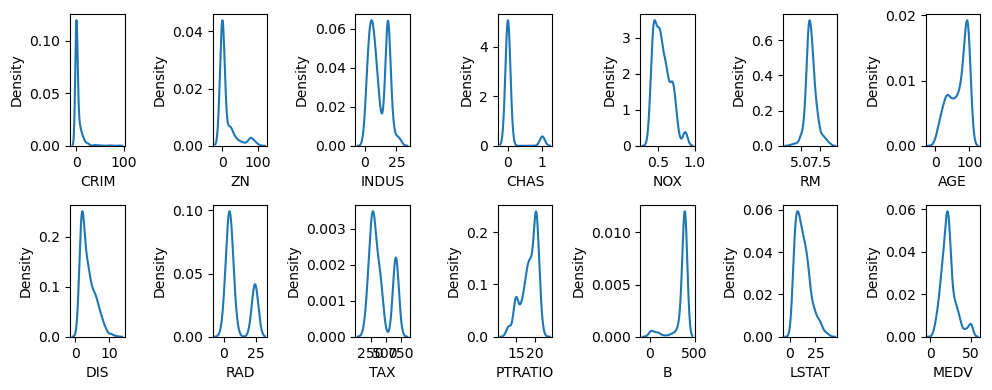

In [5]:
fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(10, 4))
index = 0
axs = axs.flatten()
for k,v in df.items():
    sns.kdeplot(v, ax=axs[index])
    index = index + 1
plt.tight_layout()

Rozkłady pokazują istnieją kolumny (CRIM, ZN, B), które mają bardzo”ukośne” rozkłady. Nasza zmienna celu (MEDV) wygląda że ma w miarę rozkład normalny. Pozostałe cechy również wydają się mieć rozkład normalny lub bimodelny (z wyjątkiem CHAS która jest dyskretny).

## Podejście "tradycyjne" 

### Ważność cech (feature importance)

W modelach uczenia maszynowego, takich jak Random Forest, jednym z kluczowych aspektów interpretacji jest analiza ważności cech (feature importance), która jest niekiedy wbudowana w mechanizm danego algorytmu. Takie podejście pozwala zidentyfikować, które zmienne mają największy wpływ na predykcje modelu. 

W przypadku Random Forest ważność cechy jest obliczana na podstawie średniego spadku dokładności lub czystości węzłów drzew, które są uzyskiwane przez te cechy podczas procesu tworzenia drzew decyzyjnych. Dzięki temu można lepiej zrozumieć, które dane są najbardziej istotne dla modelu.

In [6]:
from sklearn.ensemble import RandomForestRegressor

In [7]:
# Przygotowanie danych
X = housing_data.drop('MEDV', axis=1)
y = housing_data['MEDV']

# Podział danych na zestawy treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Tworzenie modelu Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Wydobycie ważności cech
feature_importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)

In [8]:
# Wyświetlenie ważności cech
print(importance_df)

    Feature  Importance
5        RM    0.439585
12    LSTAT    0.379941
7       DIS    0.066120
0      CRIM    0.031731
10  PTRATIO    0.019494
11        B    0.012656
4       NOX    0.012637
6       AGE    0.012022
9       TAX    0.011789
2     INDUS    0.006785
8       RAD    0.004050
3      CHAS    0.001600
1        ZN    0.001591


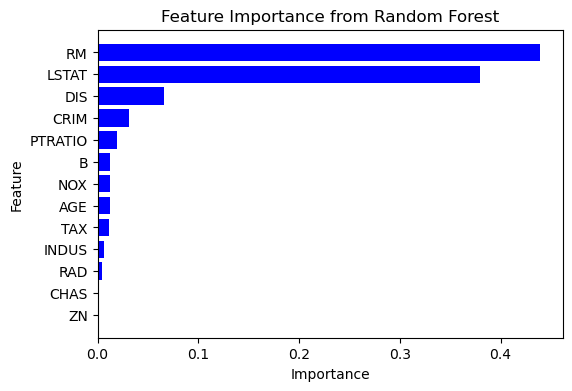

In [9]:
# Generowanie wykresu słupkowego w poziomie
plt.figure(figsize=(6, 4))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='blue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()  # Odwrócenie osi y, aby najważniejsze cechy były na górze
plt.show()

Oto ważność cech według modelu Random Forest dla zbioru danych o cenach mieszkań w Bostonie:

* **RM (średnia liczba pokoi na mieszkanie)**: 43.96% – ta cecha ma największy wpływ na medianę wartości domów, co wskazuje, że liczba pokoi jest kluczowym czynnikiem w ocenie wartości nieruchomości.
* **LSTAT (% niższego statusu populacji)**: 37.99% – niższy status społeczno-ekonomiczny również silnie wpływa na wartość nieruchomości.
* **DIS (ważone odległości do pięciu bostońskich centrów pracy)**: 6.61% – odległość od centrów zatrudnienia także ma znaczenie, ale jest mniej wpływowa niż RM i LSTAT.

Pozostałe cechy mają znacznie mniejszy wpływ na przewidywaną wartość nieruchomości. To pokazuje, jak różne atrybuty wpływają na decyzje modelu i które z nich są najważniejsze dla prognozowania cen domów. Analiza taka może być pomocna w zrozumieniu, które zmienne są kluczowe przy podejmowaniu decyzji o inwestycjach w nieruchomości lub przy optymalizacji modeli do celów wyceny.

### Ważność cech w regresji liniowej

Do oceny ważności cech, można użyć regresji liniowej , chociaż podejście to różni się od tego stosowanego w modelach takich jak Random Forest. W regresji liniowej ważność cech jest często oceniana na podstawie wartości współczynników (beta) przy poszczególnych zmiennych niezależnych. Współczynniki te wskazują, jak bardzo zmiana o jednostkę w danej cechę wpływa na zmienną zależną, przy założeniu stałości pozostałych zmiennych. 

**Interpretacja współczynników**:

* **Wartość współczynnika**: Pokazuje, ile jednostek zmiennej zależnej (np. ceny domu) zmieni się, gdy zmienna niezależna (cecha) zmieni się o jedną jednostkę.
* **Znak współczynnika**: Dodatni znak oznacza, że wzrost cechy prowadzi do wzrostu przewidywanej wartości zmiennej zależnej, natomiast ujemny znak wskazuje na odwrotną zależność.

**Ważne uwagi**:

* **Wielkość współczynnika**: Wartości bezwzględne współczynników mogą być użyte do oceny ważności cech, ale tylko wtedy, gdy zmienne są znormalizowane (tzn. mają tę samą skalę). Dla zmiennych o różnych skalach, bezwzględna wartość współczynnika niekoniecznie odzwierciedla rzeczywistą ważność.
* **Statystyczna istotność**: Współczynniki powinny być również oceniane pod kątem ich statystycznej istotności (zazwyczaj przy użyciu testu t dla każdego współczynnika), co może pomóc w ustaleniu, czy dana cecha ma istotny wpływ na zmienną zależną.

Poniżej przykładowa implementację w Pythonie, jak użyć regresji liniowej do oceny ważności cech na tych samych danych o cenach mieszkań, które wcześniej analizowaliśmy.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [11]:
# Przygotowanie danych
X = housing_data.drop('MEDV', axis=1)
y = housing_data['MEDV']

# Podział danych na zestawy treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Tworzenie modelu regresji liniowej
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Wydobycie współczynników
coefficients = lr_model.coef_
coefficients_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients}).sort_values(by='Coefficient', ascending=False)

# Obliczenie RMSE
y_pred = lr_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

print(coefficients_df)
print(f"RMSE = {rmse}")

    Feature  Coefficient
5        RM     4.057199
3      CHAS     3.119835
8       RAD     0.242727
2     INDUS     0.049523
1        ZN     0.035809
11        B     0.011794
9       TAX    -0.008702
6       AGE    -0.010821
0      CRIM    -0.133470
12    LSTAT    -0.547113
10  PTRATIO    -0.910685
7       DIS    -1.385998
4       NOX   -15.417061
RMSE = 4.638689926172808


Oto wyniki powyższej analizy regresji liniowej dotyczącej ważności cech dla predykcji mediany wartości domów (**MEDV**):

**Współczynniki dla cech**:

* **RM (średnia liczba pokoi na mieszkanie)**: Coefficient = 4.057, co wskazuje, że wzrost liczby pokoi o jeden zwiększa przewidywaną wartość domu o około 4057 dolarów.
* **CHAS (przynależność do rzeki Charles River)**: Coefficient = 3.120, sugerujący dodatkową premię dla domów przy rzece.
* **NOX (stężenie tlenków azotu)**: Coefficient = -15.417, co oznacza, że wzrost stężenia tlenków azotu o jednostkę skutkuje znacznym spadkiem wartości domu.
  
**Statystyka modelu**:

**Root Mean Square Error (RMSE)**: 4.639, co wskazuje na średni błąd predykcji ceny domu w tysiącach dolarów.

**Interpretacja**:
Współczynniki w regresji liniowej bezpośrednio wskazują na wpływ każdej cechy na zmienną zależną (MEDV). 

Największy pozytywny wpływ na wartość nieruchomości mają cechy takie jak liczba pokoi (**RM**) i przynależność do rzeki Charles (**CHAS**), podczas gdy największy negatywny wpływ ma stężenie tlenków azotu (**NOX**). Cechy takie jak **LSTAT** (% niższego statusu populacji) i **PTRATIO** (stosunek uczniów do nauczycieli) również mają znaczący negatywny wpływ na wartość nieruchomości.

<b style="color: red;">Ważne jest, aby pamiętać, że współczynniki te mają sens tylko wtedy, gdy inne zmienne w modelu są utrzymywane na stałym poziomie, a dane są prawidłowo skalowane i przygotowane do analizy.</b>

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
# Normalizacja danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Podział znormalizowanych danych na zestawy treningowe i testowe
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Ponowne utworzenie modelu regresji liniowej na znormalizowanych danych
lr_model_scaled = LinearRegression()
lr_model_scaled.fit(X_train_scaled, y_train)

# Wydobycie współczynników
coefficients_scaled = lr_model_scaled.coef_
coefficients_scaled_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients_scaled}).sort_values(by='Coefficient', ascending=False)

# Obliczenie RMSE dla znormalizowanych danych
y_pred_scaled = lr_model_scaled.predict(X_test_scaled)
rmse_scaled = root_mean_squared_error(y_test, y_pred_scaled)

print(coefficients_scaled_df)
print(f"RMSE = {rmse_scaled}")

    Feature  Coefficient
5        RM     2.847839
8       RAD     2.111400
11        B     1.075678
1        ZN     0.834326
3      CHAS     0.791636
2     INDUS     0.339407
6       AGE    -0.304293
0      CRIM    -1.146914
9       TAX    -1.465200
4       NOX    -1.784727
10  PTRATIO    -1.969635
7       DIS    -2.915625
12    LSTAT    -3.903107
RMSE = 4.638689926172828


Po normalizacji danych i ponownym przetrenowaniu modelu regresji liniowej, oto interpretacja ważności cech wraz z ich współczynnikami:

**Współczynniki dla znormalizowanych cech**:

- **RM (średnia liczba pokoi na mieszkanie)**: Coefficient = 2.848, co potwierdza, że jest to bardzo istotna cecha wpływająca pozytywnie na wartość nieruchomości.
- **LSTAT (% niższego statusu populacji)**: Coefficient = -3.903, największy ujemny wpływ na wartość domu, wskazujący, że wyższy procent osób o niższym statusie społecznym w danym obszarze znacząco obniża ceny nieruchomości.
- **DIS (ważone odległości do pięciu bostońskich centrów pracy)**: Coefficient = -2.916, co sugeruje, że większa odległość od centrów pracy negatywnie wpływa na wartość nieruchomości.

**Statystyka modelu**:

- **Root Mean Square Error (RMSE)**: 4.639, średni błąd predykcji ceny domu w tysiącach dolarów, co jest niezmienione w stosunku do modelu bez normalizacji, ponieważ RMSE nie zależy od skali cech.

**Interpretacja po normalizacji**:
Normalizacja danych umożliwia bezpośrednie porównanie wpływu różnych cech, ponieważ wszystkie zmienne mają teraz tę samą skalę (średnia 0 i odchylenie standardowe 1). Wpływ cech jest teraz reprezentowany przez wartość bezwzględną ich współczynników. Największy wpływ mają cechy **RM**, **LSTAT**, i **DIS**, co wskazuje na ich znaczenie w ocenie wartości nieruchomości.

Ten model daje jasny obraz, które czynniki są najbardziej wpływowe w kontekście cen domów w Bostonie, z jednoznaczną interpretacją wpływu każdej cechy, dzięki operacji skalowania.

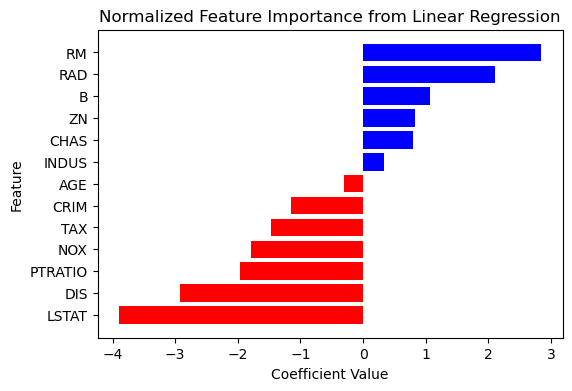

In [14]:
colors = ['red' if x < 0 else 'blue' for x in coefficients_scaled_df['Coefficient']]

# Generowanie wykresu słupkowego w poziomie dla znormalizowanych danych
plt.figure(figsize=(6, 4))
plt.barh(coefficients_scaled_df['Feature'], coefficients_scaled_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Normalized Feature Importance from Linear Regression')
plt.gca().invert_yaxis()  # Odwrócenie osi y, aby najważniejsze cechy były na górze
plt.show()

Na wykresie przedstawiono ważność cech z modelu regresji liniowej dla znormalizowanych danych. Jak widać, cechy takie jak **RM** (średnia liczba pokoi na mieszkanie), **LSTAT** (% niższego statusu populacji), i **DIS** (ważone odległości do pięciu bostońskich centrów pracy) mają największy wpływ na wartość nieruchomości, co jest zgodne z naszą wcześniejszą analizą.

### Wykorzystanie statsmodels do regresji liniowej

In [15]:
import statsmodels.api as sm

In [16]:
# Przygotowanie danych
X = housing_data.drop('MEDV', axis=1)
y = housing_data['MEDV']

# Podział danych na zestawy treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model sklearn - do predykcji i RMSE
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Wydobycie współczynników sklearn
coefficients = lr_model.coef_

# Model statsmodels - do p-value i istotności
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Tabela wyników
wyniki_df = pd.DataFrame({
    'Feature': ols_model.params.index,
    'Coefficient': ols_model.params.values,
    'p_value': ols_model.pvalues.values
})

# Określenie istotności przy alpha = 0.05
wyniki_df['Istotny (alpha=0.05)'] = wyniki_df['p_value'] < 0.05

# Sortowanie po p-value lub po wartości współczynnika
wyniki_df = wyniki_df.sort_values(by='p_value')

# Predykcja i RMSE
y_pred = lr_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

print(wyniki_df)
print(f"RMSE = {rmse}")

    Feature  Coefficient       p_value  Istotny (alpha=0.05)
13    LSTAT    -0.547113  3.221394e-18                  True
6        RM     4.057199  5.681360e-15                  True
11  PTRATIO    -0.910685  8.564091e-09                  True
8       DIS    -1.385998  2.164074e-08                  True
0     const    31.631084  3.069062e-07                  True
12        B     0.011794  4.659223e-04                  True
1      CRIM    -0.133470  1.182004e-03                  True
5       NOX   -15.417061  1.286777e-03                  True
4      CHAS     3.119835  2.809115e-03                  True
9       RAD     0.242727  3.263905e-03                  True
2        ZN     0.035809  4.325030e-02                  True
10      TAX    -0.008702  6.016873e-02                 False
3     INDUS     0.049523  4.967706e-01                 False
7       AGE    -0.010821  5.028814e-01                 False
RMSE = 4.638689926172808


p_value < 0.05 (z testu t studenta) oznacza zwykle, że dany współczynnik uznajesz za statystycznie istotny przy poziomie istotności 0.05.

In [17]:
# Pełne podsumowanie statystyczne
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     75.81
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           4.96e-92
Time:                        02:47:24   Log-Likelihood:                -1053.8
No. Observations:                 354   AIC:                             2136.
Df Residuals:                     340   BIC:                             2190.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.6311      6.056      5.223      0.0

Model regresji liniowej jest globalnie istotny statystycznie. Współczynnik determinacji R² = 0.743 oznacza, że model wyjaśnia około 74.3% zmienności ceny MEDV, a Adj. R² = 0.734 wskazuje, że dopasowanie pozostaje dobre także po uwzględnieniu liczby predyktorów. Test F (p = 4.96e-92) potwierdza, że cały model jako całość jest istotny.

Istotne statystycznie przy α = 0.05 są: CRIM, ZN, CHAS, NOX, RM, DIS, RAD, PTRATIO, B oraz LSTAT. Nieistotne są INDUS i AGE, a TAX jest na granicy istotności (p = 0.060), więc formalnie przy poziomie 0.05 nie powinien być uznany za istotny.

### Ważność cech w regresji logistycznej

Do oceny ważności cech można użyć też regresji logistycznej. W regresji logistycznej ważność cech jest najczęściej oceniana na podstawie wartości współczynników przy poszczególnych zmiennych niezależnych. Współczynniki te opisują wpływ danej cechy na logarytm ilorazu szans (log-odds) zajścia zdarzenia, przy założeniu stałości pozostałych zmiennych. Aby uzyskać bardziej intuicyjną interpretację, współczynniki często przekształca się przez funkcję wykładniczą, otrzymując ilorazy szans (odds ratios, OR).

**Interpretacja współczynników**:

Wartość współczynnika: W regresji logistycznej współczynnik informuje, o ile zmienia się logarytm szans zajścia zdarzenia, gdy dana zmienna niezależna wzrośnie o jedną jednostkę.

Iloraz szans (OR = exp(beta)): Po przekształceniu współczynnika otrzymujemy iloraz szans, który pokazuje, ile razy zmieniają się szanse zajścia zdarzenia przy wzroście danej cechy o jedną jednostkę.

**OR > 1**: wzrost cechy zwiększa szanse zajścia zdarzenia,

**OR < 1**: wzrost cechy zmniejsza szanse zajścia zdarzenia,

**OR = 1**: cecha nie wpływa na szanse zajścia zdarzenia.

Znak współczynnika: Dodatni współczynnik oznacza wzrost szans zajścia zdarzenia, a ujemny ich spadek.

**Ważne uwagi**:

* Wielkość współczynnika: Bezwzględne wartości współczynników mogą być użyte do porównywania ważności cech, ale tylko wtedy, gdy zmienne są na porównywalnej skali. W praktyce oznacza to, że dla rzetelnej oceny warto wcześniej zmienne standaryzować.

* Interpretacja OR zależy od skali cechy: Jeśli zmienna zmienia się w dużych jednostkach, iloraz szans dla wzrostu o 1 jednostkę może być mało intuicyjny. W takich przypadkach warto interpretować OR dla sensownej zmiany, np. o 10 jednostek.

* Statystyczna istotność: Współczynniki powinny być oceniane również pod kątem istotności statystycznej, najczęściej za pomocą testu Walda, wartości p oraz przedziałów ufności dla ilorazu szans. Pozwala to ocenić, czy dana cecha ma istotny wpływ na prawdopodobieństwo zajścia zdarzenia.

* Nie jest to bezpośrednia zmiana prawdopodobieństwa: W przeciwieństwie do regresji liniowej, współczynnik w regresji logistycznej nie mówi bezpośrednio, o ile zmienia się prawdopodobieństwo. Opisuje on zmianę log-szans, a wpływ na samo prawdopodobieństwo zależy od punktu wyjścia.

Poniżej przykładowy kod. W celu zrealizowania zadania klasyfikacji, przyjęto podział dotychczasowej zmiennej wyjściowej:

* `1` = cena domu **wyższa od średniej**
* `0` = cena domu **niższa lub równa średniej**

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
# Przygotowanie danych
X = housing_data.drop('MEDV', axis=1)
srednia_cena = housing_data['MEDV'].mean()
y = (housing_data['MEDV'] > srednia_cena).astype(int)

# Podział danych na zestawy treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Tworzenie modelu regresji logistycznej
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

# Wydobycie współczynników
coefficients = log_model.coef_[0]
odds_ratios = np.exp(coefficients)

coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Odds_Ratio': odds_ratios
}).sort_values(by='Coefficient', ascending=False)

# Predykcja i ocena modelu
y_pred = log_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(coefficients_df)
print(f"Accuracy = {accuracy}")

    Feature  Coefficient  Odds_Ratio
5        RM     0.835475    2.305908
8       RAD     0.279445    1.322395
3      CHAS     0.218771    1.244546
1        ZN     0.008547    1.008583
11        B    -0.000038    0.999962
9       TAX    -0.008585    0.991452
6       AGE    -0.026437    0.973909
0      CRIM    -0.043668    0.957272
2     INDUS    -0.133339    0.875168
12    LSTAT    -0.277868    0.757396
4       NOX    -0.453298    0.635529
10  PTRATIO    -0.539418    0.583087
7       DIS    -0.546117    0.579194
Accuracy = 0.8552631578947368


Jak to interpretować:

* **Coefficient**:

  * dodatni: wzrost cechy zwiększa szanse, że dom będzie miał cenę **powyżej średniej**,
  * ujemny: wzrost cechy zmniejsza te szanse.
    
* **Odds_Ratio = exp(coefficient)**:

  * `> 1` zwiększa szanse klasy 1,
  * `< 1` zmniejsza szanse klasy 1,
  * `= 1` brak wpływu.

**Ważna uwaga**:

* podobnie jak w regresji liniowej, jeśli cechy są w różnych skalach, to porównywanie samych współczynników między cechami nie jest w pełni miarodajne; wtedy najlepiej wcześniej zastosować standaryzację.

### Wykorzystanie statsmodels do regresji logistycznej

Dla regresji logistycznej też można użyć statsmodels i wtedy uzyskuje się m.in. p-value, błędy standardowe, przedziały ufności oraz pełne summary(). W module modeli dyskretnych statsmodels obsługuje modele binarne typu Logit, a obiekt wynikowy udostępnia pvalues. 

**Ważna różnica**: **sklearn.LogisticRegression** służy głównie do predykcji i domyślnie stosuje regularyzację, natomiast **statsmodels.Logit** jest wygodniejszy do wnioskowania statystycznego o współczynnikach. Dlatego współczynniki i istotność z statsmodels nie muszą być identyczne z tymi ze sklearn. To naturalne, nie błąd.

In [20]:
import statsmodels.api as sm

In [21]:
# Przygotowanie danych
X = housing_data.drop('MEDV', axis=1)
srednia_cena = housing_data['MEDV'].mean()
y = (housing_data['MEDV'] > srednia_cena).astype(int)

# Podział danych
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Model sklearn - do predykcji i accuracy
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

# Model statsmodels - do istotności współczynników
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm).fit()

# Współczynniki, OR, p-value, przedziały ufności
przedzialy_ufnosci = logit_model.conf_int()
przedzialy_ufnosci.columns = ['CI_low', 'CI_high']

wyniki_df = pd.DataFrame({
    'Feature': logit_model.params.index,
    'Coefficient': logit_model.params.values,
    'Odds_Ratio': np.exp(logit_model.params.values),
    'p_value': logit_model.pvalues.values,
    'CI_low_OR': np.exp(przedzialy_ufnosci['CI_low'].values),
    'CI_high_OR': np.exp(przedzialy_ufnosci['CI_high'].values)
})

wyniki_df['Istotny (alpha=0.05)'] = wyniki_df['p_value'] < 0.05
wyniki_df = wyniki_df.sort_values(by='p_value')

# Predykcja i ocena modelu sklearn
y_pred = log_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

wyniki_df.head(13)

Optimization terminated successfully.
         Current function value: 0.283857
         Iterations 8


,Feature,Coefficient,Odds_Ratio,p_value,CI_low_OR,CI_high_OR,Istotny (alpha=0.05)
13,LSTAT,-0.267797,7.650634e-01,0.000004,6.831672e-01,8.567770e-01,True
11,PTRATIO,-0.552888,5.752863e-01,0.000162,4.316129e-01,7.667850e-01,True
8,DIS,-0.638141,5.282736e-01,0.000265,3.749247e-01,7.443441e-01,True
9,RAD,0.282079,1.325884e+00,0.000291,1.138255e+00,1.544441e+00,True
0,const,16.160761,1.043588e+07,0.001161,6.075586e+02,1.792546e+11,True
6,RM,0.989132,2.688900e+00,0.032557,1.085629e+00,6.659905e+00,True
7,AGE,-0.024103,9.761851e-01,0.033901,9.546853e-01,9.981691e-01,True
10,TAX,-0.007561,9.924675e-01,0.049362,9.850126e-01,9.999789e-01,True
5,NOX,-6.821859,1.089693e-03,0.087864,4.316274e-07,2.751056e+00,False
3,INDUS,-0.106583,8.989009e-01,0.099559,7.918223e-01,1.020460e+00,False


In [22]:
print(f"Accuracy = {accuracy:.4f}")

Accuracy = 0.8553


In [23]:
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                   MEDV   No. Observations:                  354
Model:                          Logit   Df Residuals:                      340
Method:                           MLE   Df Model:                           13
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.5812
Time:                        02:47:25   Log-Likelihood:                -100.49
converged:                       True   LL-Null:                       -239.92
Covariance Type:            nonrobust   LLR p-value:                 6.280e-52
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.1608      4.975      3.248      0.001       6.409      25.912
CRIM          -0.0528      0.056     -0.939      0.348      -0.163       0.057
ZN             0.0065      0.014      0.452      0.6

Jak to czytać:
* Coefficient > 0 oznacza wzrost log-ilorazu szans,
* Odds_Ratio = exp(coef) > 1 oznacza wzrost szans klasy 1,
* p_value < 0.05 oznacza istotność statystyczną współczynnika,
* CI_low_OR i CI_high_OR to 95% przedział ufności dla ilorazu szans. 

Interpretacja:
* Model regresji logistycznej jest istotny statystycznie jako całość (`LLR p-value = 6.280e-52`), co oznacza, że zestaw predyktorów dobrze odróżnia mieszkania o wartości `MEDV` powyżej i poniżej średniej. Pseudo `R² = 0.5812` wskazuje na dość dobre dopasowanie modelu.
* Istotne statystycznie przy `α = 0.05` są zmienne: `RM`, `AGE`, `DIS`, `RAD`, `TAX`, `PTRATIO` oraz `LSTAT`. Dodatni wpływ na prawdopodobieństwo zaklasyfikowania obserwacji do grupy z wyższą wartością `MEDV` mają `RM` i `RAD`, natomiast `AGE`, `DIS`, `TAX`, `PTRATIO` i `LSTAT` działają w kierunku przeciwnym.
* Spośród wszystkich cech szczególnie wyraźne znaczenie mają `LSTAT`, `PTRATIO`, `DIS` i `RAD`, bo są silnie istotne i mają stosunkowo duże statystyki `z`. Z kolei `CRIM`, `ZN`, `CHAS` i `B` nie wykazują istotnego wpływu w tym modelu, ponieważ ich `p-value` są większe od 0.05.

## Wartość Shapley’a – interpretacja modeli blackbox

### Biblioteka SHAP

<img src=".//Images//shap_header.png" alt="Shape" width="300" height="200" style="margin: 10px;"/>

SHAP (SHapley Additive exPlanations) jest biblioteką wykorzystującą w praktyczny sposób podejście z teorii gier do wyjaśnienia wyniku dowolnego modelu uczenia maszynowego. Scott Lunberg (https://github.com/slundberg) udostępnił pierwszą wersję w 2016. Scott z zespołem opracował optymalną metodę alokacji kredytu wykorzystującą klasyczne wartości Shapley’a z teorii gier i powiązanych z nimi rozszerzeń (wszystkie szczegółowe informacje i cytowania znajdują się w dokumentacji biblioteki) do wyjaśniania modeli.

**pip install shap**   lub   **conda install -c conda-forge shap**

Interpretacja modeli uczenia maszynowego w oparciu o wartości Shapleya (SHAP values) to zaawansowana metoda wyjaśniająca, jak poszczególne cechy przyczyniają się do przewidywanej decyzji modelu dla konkretnego przypadku. Metoda ta korzysta z koncepcji pochodzącej z teorii gier, która pozwala rozdzielić "wygraną" (tutaj przewidywanie modelu) między wszystkie "graczy" (cechy).

**Jak to działa?**

1. **Podejście kooperacyjne**: Wartości Shapleya traktują każdą cechę w zestawie danych jako "gracza" w grze kooperacyjnej, gdzie przewidywanie modelu jest "wygraną", którą należy rozdzielić.
2. **Obliczenia**:
   * Wartość Shapleya dla każdej cechy jest obliczana poprzez przeglądanie wszystkich możliwych kombinacji cech, które mogą pojawić się w modelu.
   * Dla każdej kombinacji, model jest trenowany z cechą i bez cechy, aby zobaczyć, jak jej dodanie lub usunięcie wpływa na wynik modelu.
   * Średnia różnica w przewidywaniach z cechą i bez niej wskazuje na jej przyczynowy wpływ na przewidywanie.
3. **Wizualizacja**:
   * Wartości Shapleya mogą być wizualizowane dla poszczególnych obserwacji, co pokazuje, jak każda cecha wpłynęła na konkretne przewidywanie.
   * Pozwala to zrozumieć, dlaczego model podjął określoną decyzję, wskazując na cechy, które miały największy dodatni lub ujemny wpływ na wynik.

**Zalety stosowania wartości Shapleya**:

* **Sprawiedliwość**: Każda cecha jest "sprawiedliwie" oceniana na podstawie jej wkładu, niezależnie od innych cech.
* **Zrozumiałość**: Wartości te pozwalają na głębsze zrozumienie modeli, które mogą być z natury skomplikowane i nieprzejrzyste (np. głębokie sieci neuronowe).
* **Precyzja**: Oferują dokładniejsze i teoretycznie uzasadnione podejście do interpretacji niż inne metody.

Interpretacja oparta na wartościach Shapleya jest bardzo pomocna w przypadkach, gdy ważne jest zrozumienie i zaufanie do działania modelu, takich jak diagnozy medyczne, decyzje kredytowe czy inne aplikacje, gdzie transparentność decyzji AI jest kluczowa.

### Przykład

Chcąc zobrazować, jak wartości Shapleya działają w praktyce, użyjemy prostego modelu regresji do przewidywania ceny domu na podstawie kilku cech. Załóżmy, że mamy model, który używa trzech cech:

* **Powierzchnia domu (RM)**: Liczba metrów kwadratowych.
* **Lokalizacja (LOC)**: Wartość 1 dla prestiżowej dzielnicy, 0 w przeciwnym razie.
* **Wiek domu (AGE)**: W latach.

Przykładem może być dom o następujących cechach:
* **Powierzchnia**: 100 m²
* **Lokalizacja**: Prestiżowa (1)
* **Wiek**: 5 lat

Załóżmy, że model regresji przewiduje cenę tego domu na 500,000 zł. Chcemy teraz dowiedzieć się, jak duży wpływ na tę cenę mają poszczególne cechy, korzystając z wartości Shapleya.

1. **Analiza wszystkich kombinacji**:
   - **Tylko RM**: Jeśli model użyje tylko cechy RM, przewiduje cenę na 300,000 zł.
   - **Tylko LOC**: Przy tylko tej cechy cena wynosi 450,000 zł.
   - **Tylko AGE**: W tym przypadku przewidziana cena to 200,000 zł.
   - **RM + LOC**: Razem te cechy dają cenę 480,000 zł.
   - **RM + AGE**: Cena wynosi 320,000 zł.
   - **LOC + AGE**: Przewidywana cena to 460,000 zł.
   - **RM + LOC + AGE**: Pełna cena wynosi 500,000 zł.

2. **Obliczenia wartości Shapleya**:
   - Dla **RM**:
     - Wpływ dodania RM, gdy nie ma żadnej cechy: 300,000 - 0 = 300,000
     - Wpływ dodania RM do LOC: 480,000 - 450,000 = 30,000
     - Wpływ dodania RM do AGE: 320,000 - 200,000 = 120,000
     - Wpływ dodania RM, gdy są LOC + AGE: 500,000 - 460,000 = 40,000
     - **Wartość Shapleya dla RM**: Średnia z tych wartości = 122,500.

   - Analogicznie dla **LOC** i **AGE**.

3. **Wnioski**:
   - **RM** ma największy wpływ, gdy jest jedyną cechą, co sugeruje, że jest to istotny czynnik sam w sobie.
   - **LOC** ma duży wpływ samodzielnie, ale mniejszy, gdy dodajemy inne cechy.
   - **AGE** ma mniejszy wpływ, co wskazuje, że jest mniej istotny w porównaniu z innymi cechami.

Ten przykład pokazuje, jak można zastosować wartości Shapleya do analizy wpływu poszczególnych cech na wynik modelu regresji. Jest to szczególnie użyteczne w interpretowaniu, które cechy mają największe znaczenie i jak one współdziałają, przyczyniając się do końcowego przewidywania.

### Budowa modelu
Zbudujmy teraz prosty model służący do przewidywania cen. Oczywiście model może być znacznie lepszy, niemniej celem tego wpisu jest wyjaśnienie jak go zinterpretować, więc nie koncentrowałem się na przygotowaniu odpowiednio na pracy nad charakterystykami, wybraniu najlepszego zestawu cech czy dobraniu optymalnego modelu z hiperparametrami.

In [24]:
# Przygotowanie danych
X = housing_data.drop('MEDV', axis=1)
y = housing_data['MEDV']

# Podział danych na zestawy treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = xgb.XGBRegressor(max_depth=3, n_estimators=250, colsample_bytree=0.75, seed=2020)
model.fit(X_train, y_train)
 
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print(f'Błąd na próbce val: {root_mean_squared_error(y_test, y_pred_test)}. Na train: {root_mean_squared_error(y_train, y_pred_train)}')

Błąd na próbce val: 2.9121823881542346. Na train: 0.15047243167124402


### Wczytanie biblioteki SHAP
Wczytujemy bibliotekę:

In [25]:
import shap 

a teraz wystarczy utworzyć obiekt, który pomoże wyliczyć wartości Shapley’a:

In [26]:
explainer = shap.TreeExplainer(model)

Zwróćcie proszę uwagę, że w powyższym kodzie stworzyliśmy wartości SHAP na podstawie odwołania się do modeli drzewiastych poprzez funkcję shap.TreeExplainer (i tutaj nasz model). Ale pakiet SHAP zawiera wyjaśnienia dla prawie każdego typu modelu.

* shap.DeepExplainer – działa z modelami Deep Learning,
* shap.KernelExplainer – działa ze wszystkimi modelami, ale kosztem tego, że jest wolniejszy niż pozostałe „Explainers” i oferuje przybliżenie wartości Shapley’a.

Teraz obliczmy wartości shap_values dla wszystkich wartości naszego zbioru. W poniższym przykładzie wyliczono dla wartości zbioru walidacyjnego by na nim zinterpretować jak działają charakterystyki. 

UWAGA! poniższy kod może długo się przeliczać dla dużych zbiorów.

In [27]:
shap_values = explainer.shap_values(X_test)
print(f'Shape: {shap_values.shape}')
pd.DataFrame(shap_values).head(3)

Shape: (152, 13)


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.399107,-0.001756,-0.121359,-0.000967,0.167964,-1.413855,-1.197069,0.214144,0.158511,-0.069757,0.867136,0.093411,0.665209
1,-0.792000,-0.023923,-0.773522,-0.018807,0.390968,0.726067,1.411010,0.739805,-0.050260,0.075884,0.538854,-0.209849,7.668813
2,0.584943,-0.028361,-0.246026,-0.005559,0.505756,-2.334962,-0.818503,-0.136310,-0.264723,-0.559299,-0.683061,0.132030,-3.880294


Powyżej widzicie, że dla każdego wiersza (obserwacji) i charakterystyki (cechy) zostały wyliczone wartości shap (analogicznie jak w przykładzie z restauracją i moimi córeczkami). Teraz spróbujmy przygotować kilka wykresów i je zinterpretować.

### Ogólna interpretowalność – wykres istotności
Pierwszym wykresem jest wykres z globalną interpretowalność. Sumaryczne wartości SHAP mogą pokazać, w jakim stopniu każda cecha przyczyniła się do przewidywania zmiennej docelowej.

Wykres ważności zmiennych zawiera listę najbardziej znaczących zmiennych w porządku malejącym. Górne charakterystyki wnoszą najwięcej do modelu. Im niżej tym słabsza cecha i mają mniejszą moc predykcyjną.

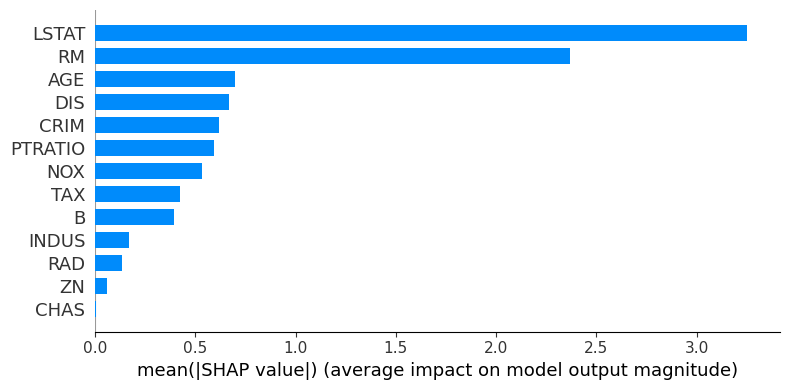

In [28]:
shap.summary_plot(shap_values, X_test, plot_type='bar', plot_size=(8,4))

Zatem dwoma najmocniejszymi zmiennymi w naszym modelu są LSTAT oraz RM a najsłabszymi ZN oraz CHAS.

Powyższy wykres można narysować pokazując dodatkowo pozytywne i negatywne relacje wartości ze zmienną docelową.

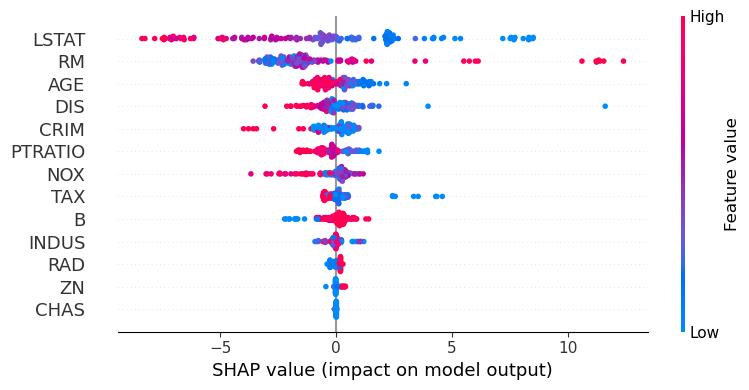

In [29]:
shap.summary_plot(shap_values, X_test, plot_type='dot', plot_size=(8,4))

Zwróćcie uwagę na to, że zachowana jest ta sama kolejność zmiennych na wykresie. On również pokazuje od najmocniejszej cechy do najsłabszej w modelu.

Każda kropka na wykresie reprezentuje jedną obserwacje na zbiorze danych (w moim przypadku walidacyjny). Ten wykres składa się ze wszystkich kropek w danych pociągu. Pokazuje następujące informacje:

* **Kolor**: pokazuje czy zmienna przyjmuje wysokie wartości (czerwony) czy niskie (niebieski) dla tej obserwacji.
* **Położenie** w poziomie: informuje czy wpływ tej wartości jest związany z wyższą prognozą czy niższą (wszystko na lewo od 0 wpływa negatywnie a wszystko na prawo pozytywnie).
* **Rozkład** kropek: dodatkowo można odczytać uproszczony rozkład zmiennej. Dużo kropek w jednym miejscu oznacza, że większość obserwacji jest w tym jednym miejscu.

Wartość shapleya interpretowalność:

Teraz zinterpretujmy LSTAT. Od razu można zwrócić uwagę , że niska wartość LSTAT ma duży pozytywny wpływ na wycenę nieruchomości. Wartość „HIGH” na wykresie przechodzi z czerwonego na niebieski.

Natomiast RM można powiedzieć, że jest odwrotnie skorelowane z ceną nieruchomości: im wyższa wartość tym wyższą cenę przewiduje model.

Pamiętajcie: wszystkie wartości po lewej stronie reprezentują obserwacje, które przesuwają przewidywaną wartość w kierunku ujemnym (czyli tutaj obniżają wartość nieruchomości), podczas gdy punkty po prawej stronie przyczyniają się do przesunięcia prognozy w kierunku dodatnim (tutaj zwiększają wycenę nieruchomości).

### Ogólna interpretowalność – wykres zależności
Spójrzmy teraz na tzw. wykres zależności, który pokazuje czy istnieje jakiś związek między celem a obiektem, tzn. czy jest liniowy czy bardziej złożony. Powyższe wykresy dają nam zbiorcze ogólne informacje a wykresy zależności dają bardzo precyzyjną informację dla pojedynczej charakterystyki.

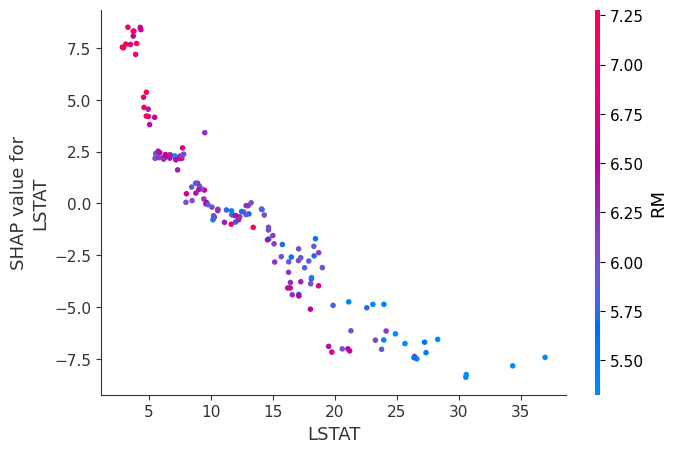

In [30]:
shap.dependence_plot('LSTAT', shap_values, X_test, interaction_index='RM') # interaction_index może być "auto" lub None

Każda kropka reprezentuje rząd danych. Położenie w poziomie to rzeczywista wartość z zestawu danych, a położenie w pionie pokazuje, co ta wartość miała dla prognozy. Fakt, że pochyla się w dół oznacza, że im wyższa wartość LSTAT to tym niższa wartość nieruchomości. I prosto można odczytać liniową zależność cechy LSTAT od zmiennej przewidywanej.

Dodatkowo automatycznie w tym przypadku dobierana jest inna zmienna najbardziej skorelowana z LSTAT. W tym przypadku jest to DIS. Kolory tutaj też odpowiadają za wartość obserwacji – tutaj zmiennej dobranej. Widzimy, że wyższe wartości zmiennej DIS są dla mniejszych wartości LSTAT.

Sprawdźmy jak wygląda druga najmocniesza cecha RM:

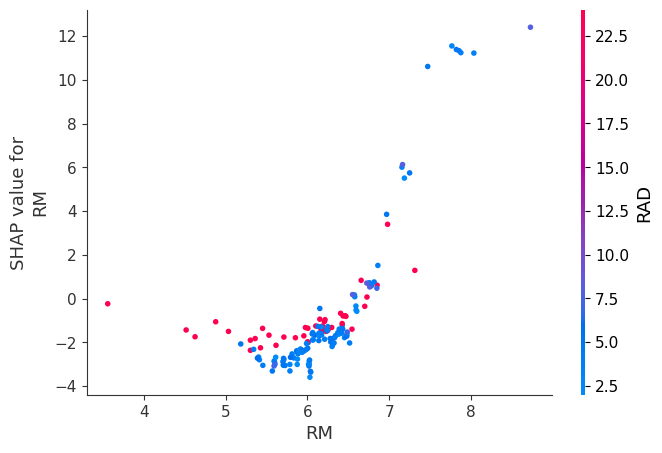

In [31]:
shap.dependence_plot('RM', shap_values, X_test)

Również tutaj zależność jest dość widoczna.

### Lokalna interpretowalność – wykres dla pojedynczej obserwacji
Podczas przeliczania każda obserwacja otrzymała swój własny zestaw wartości SHAP. Dzięki temu dla każdej obserwacji możemy sprawdzić jak każda zmienna z modelu wpłynęła i w jakim stopniu na podjęcie takiej decyzji przez model. Możemy w prosty i przejrzysty sposób wyjaśnić, dlaczego model zwrócił taką prognozę. Lokalna interpretowalność pozwala nam określić i sprawdzić wpływ każdego z czynników.

W pierwszym kroku należy zainicjować niezbędne biblioteki JavaScript do interaktywnych wykresów w Jupyter Notebooku (bez tego dostaniemy błędy przy próbie wywołania poniższych wykresów):

In [32]:
shap.initjs()

i wyświetlmy wynik dla naszej pierwszej obserwacji (przypominam, że wiersze są iterowane od wartości zero):

In [33]:
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])

Opiszmy co widać na wykresie (pierwszy raz jak zobaczyłem to nie wiedziałem co się na nim dzieje 🙂 ):

* **output value** – jest to wartość prognozowana dla naszej obserwacji przez nasz model. 
* **base value** – jest to średnia wartość predykcji zwracana dla naszych obserwacji. Możesz to prosto sprawdzić:

In [34]:
y_pred_train.mean() # średnia na zbierze treningowym

23.015741

* **Kolory**: zmienne (cechy) podnoszące prognozę (w tym przypadku zwiększające cenę nieruchomości) są pokazane na czerwono, a te, które zmniejszają prognozę na niebiesko (mniejsza cena mieszkania). Cechy są poustawiane w kolejności które najbardziej wpłynęły odpowiednio na plus i minus.

Popatrzmy na obserwację 17, 23, 54:

In [35]:
print('Obserwacja nr: 17')
shap.force_plot(explainer.expected_value, shap_values[17], X_test.iloc[17])

Obserwacja nr: 17


In [36]:
print('Obserwacja nr: 23')
shap.force_plot(explainer.expected_value, shap_values[23], X_test.iloc[23])

Obserwacja nr: 23


In [37]:
print('Obserwacja nr: 54')
shap.force_plot(explainer.expected_value, shap_values[54], X_test.iloc[54])

Obserwacja nr: 54


Jak widzicie można popatrzeć na każdą obserwację i wyjaśnić, która cecha wpłynęła na model.

### Wykresy kaskadowe

Ten typ wykresu przedstawia wyjaśnienie pojedynczej prognozy w formie wykresu kaskadowego.

Wartość SHAP danej cechy reprezentuje wpływ cech na wynik modelu. Wykres kaskadowy jest zaprojektowany, aby wizualnie pokazać, w jaki sposób wartości SHAP każdej cechy przesuwają wynik modelu z naszych wcześniejszych oczekiwań w ramach rozkładu danych do ostatecznej prognozy modelu, biorąc pod uwagę wkłady wszystkich cech.

Cechy są sortowane według wielkości ich wartości SHAP, przy czym cechy o najmniejszej wielkości są grupowane na dole wykresu, gdy liczba cech w modelach przekracza max_displayparametr.

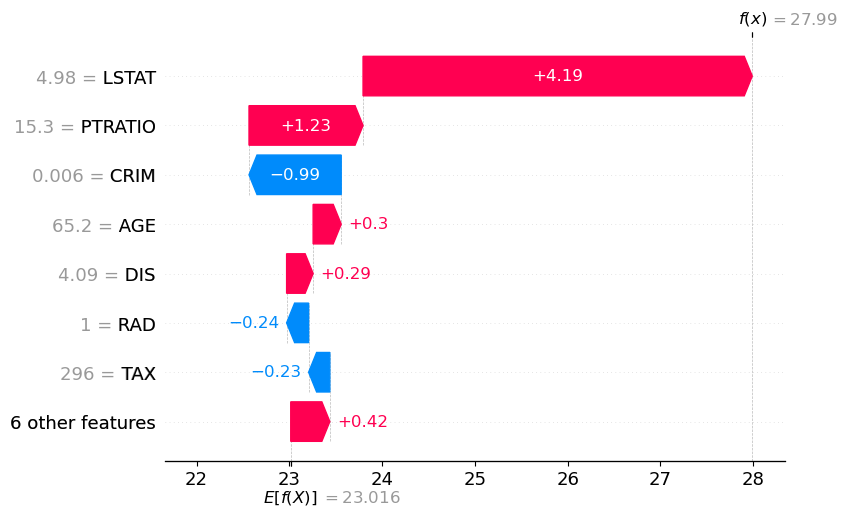

In [38]:
explainer = shap.Explainer(model)
shap_values_e = explainer(X)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values_e[0], max_display=8)

Jak widzicie można popatrzeć na każdą obserwację i wyjaśnić która cecha wpłynęła na model. 

### Wyjaśnienie całego zbioru
SHAP daje nam jeszcze jedną super (moim zdaniem) funkcjonalność. Powyżej mieliśmy zestawienie dla pojedynczej obserwacji. Natomiast jeśli weźmiemy wiele wyjaśnień, takich jak to pokazane powyżej, obrócimy je o 90 stopni, a następnie ułóżymy je poziomo to możemy zobaczyć wyjaśnienia dla całego zestawu danych (w notatniku ten wykres jest interaktywny):

In [39]:
shap.force_plot(explainer.expected_value, shap_values, X_test)

Wykres jest interaktywny i można spojrzeć osobno na każdą zmienną odpowiednio wybierając po obu stronach osi tą samą cechę:

<img src=".//Images//shap_1.png" alt="Wartość shap" width="600" height="400"/>

Spójrzcie na wyniki, które można łatwo interpretować kiedy wartość cechy wpływa na plus a kiedy na minus:

<img src=".//Images//shap_2.png" alt="Wartość shap" width="600" height="400"/>
A: dla cechy LSTAT
<img src=".//Images//shap_3.png" alt="Wartość shap" width="600" height="400"/>
B: dla cechy RM
<img src=".//Images//shap_4.png" alt="Wartość shap" width="600" height="400"/>
C: dla cechy PTRATIO

## LIME

Local Interpretable Model-agnostic Explanations (w skrócie **LIME**). Zamiast zapewniać globalne zrozumienie modelu w całym zestawie danych, LIME koncentruje się na wyjaśnianiu prognozy modelu dla poszczególnych wystąpień.

pip install lime

https://github.com/marcotcr/lime

In [40]:
import warnings
warnings.filterwarnings("ignore")

In [41]:
# Import the LimeTabularExplainer module
import lime
import sklearn.ensemble
from lime.lime_tabular import LimeTabularExplainer

# Get the feature names
feature_names = list(X_train.columns)

explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=feature_names, 
                                                   class_names=['MEDV'], 
                                                   verbose=True, mode='regression')

In [42]:
rf = sklearn.ensemble.RandomForestRegressor(n_estimators=1000)
rf.fit(X_train, y_train);

In [43]:
i = 25
exp = explainer.explain_instance(X_test.iloc[i], rf.predict, num_features=5)

Intercept 27.126528886744865
Prediction_local [15.41514358]
Right: 15.244500000000079


In [44]:
# exp.show_in_notebook(show_table=True) bład w nowym Jupyter :(
from IPython.display import display, HTML
display(HTML(exp.as_html(show_table=True)))

Wynik zawiera trzy główne informacje (od lewej do prawej): (1) przewidywania modelu, (2) wkład cech i (3) rzeczywistą wartość każdej cechy.

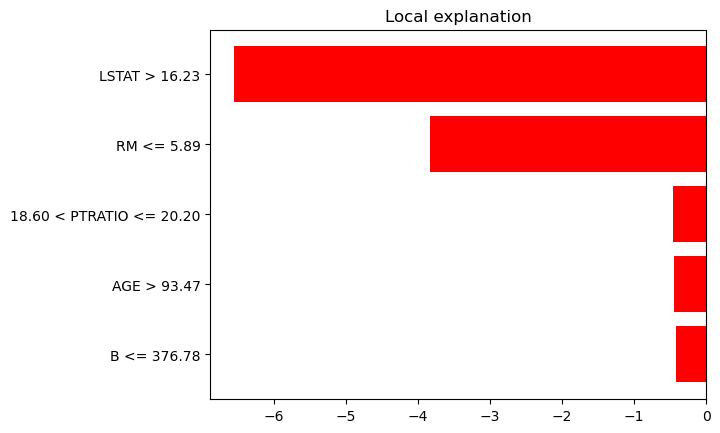

In [45]:
fig = exp.as_pyplot_figure()

In [46]:
exp.as_list()

[('LSTAT > 16.23', -6.5525672832884245),
 ('RM <= 5.89', -3.835964967779809),
 ('18.60 < PTRATIO <= 20.20', -0.45877925664512587),
 ('AGE > 93.47', -0.4432394551938815),
 ('B <= 376.78', -0.4208343424376334)]

## Podsumowanie

SHAP i LIME to nie jedyne frameworki, które możemy użyć do interpretowalności modeli. Zaliczają się też do nich przykładowo:

* DALEX https://github.com/pbiecek/DALEX
* ELI5 https://eli5.readthedocs.io/en/latest/

Interpretowalność jest bardzo ważnym aspektem uczenia maszynowego i sztucznej inteligencji. Mam nadzieję, że te przykłady pokazują Wam, że można zrozumieć wszelkie modele i mamy odpowiednie narzędzia, które bardzo mogą ułatwić nam pracę.

## Zadania
### Zadanie 1

Dla poniższych modeli zinterpretuj ważność cech dla danych *diabetes* (uwaga istnieją przynajmniej 2 bazy o tej samej nazwie).

Oto lista kolumn w zbiorze danych:
* **AGE**: Wiek pacjenta w latach (typ: int).
* **SEX**: Płeć pacjenta, zakodowana jako 1 lub 2 (typ: int).
* **BMI**: Body Mass Index, wskaźnik masy ciała (typ: float).
* **BP**: Średnie ciśnienie krwi pacjenta (typ: float).
* **S1**: T1, całkowite stężenie T-Chol (cholesterolu) w surowicy (typ: int).
* **S2**: T2, niskie stężenie LDL cholesterolu w surowicy (typ: float).
* **S3**: T3, wysokie stężenie HDL cholesterolu w surowicy (typ: float).
* **S4**: T4, całkowite stężenie cholesterolu VLDL w surowicy (typ: float).
* **S5**: T5, logarytm stężenia triglicerydów w surowicy (typ: float).
* **S6**: T6, stężenie glukozy w surowicy (typ: int).
* **Y**: Zmienna zależna, ilościowa miara progresji choroby cukrzycowej rok po bazowym poziomie (typ: int).

In [47]:
data_path = ".\\data\\diabetes.csv"
diabetes_data = pd.read_csv(data_path, sep='\t')
# Wyświetlenie pierwszych kilku wierszy danych
diabetes_data.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [48]:
# Przygotowanie danych
X = diabetes_data.drop('Y', axis=1)
y = diabetes_data['Y']

# Podział danych na zestawy treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [49]:
from sklearn.metrics import root_mean_squared_error

In [50]:
def print_rmse(f):
    print(f"Root mean squared test error = {root_mean_squared_error(y_test, f(X_test)):.3f}")

**Model z wykorzystaniem regresji liniowej**

In [51]:
from sklearn import linear_model
lin_regr = linear_model.LinearRegression()
lin_regr.fit(X_train, y_train)
print_rmse(lin_regr.predict)

Root mean squared test error = 53.120


**Model z wykorzystaniem regresji logistycznej**

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Zmiana na klasyfikację
prog = y_train.median()
y_train_lr = (y_train > prog).astype(int)
y_test_lr = (y_test > prog).astype(int)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train_lr)
y_pred = log_reg.predict(X_test)

print(f"Accuracy = {accuracy_score(y_test_lr, y_pred):.3f}")

Accuracy = 0.767


**Model z wykorzystaniem drzewa decyzyjnego**

In [53]:
from sklearn import tree
dtree = tree.DecisionTreeRegressor(min_samples_split=20)
dtree.fit(X_train, y_train)
print_rmse(dtree.predict)

Root mean squared test error = 67.360


**Model z wykorzystaniem lasów losowych**

In [54]:
from sklearn.ensemble import RandomForestRegressor
rforest = RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_split=2, random_state=0)
rforest.fit(X_train, y_train)
print_rmse(rforest.predict)

Root mean squared test error = 53.870


**Model z wykorzystaniem sieci neuronowych**

In [55]:
# UWAGA: w przypadku nn można się wcześniej zastanowić nad standaryzacją
from sklearn.neural_network import MLPRegressor
nn = MLPRegressor(solver="lbfgs", alpha=1e-1, hidden_layer_sizes=(5, 2), random_state=0, max_iter=1000)
nn.fit(X_train, y_train)
print_rmse(nn.predict)

Root mean squared test error = 57.657


### Zadanie 2

Wybierz dowolny model i zrealizuj interpretację na bazie *iris*.

## Bibliografia

https://pwr-ai.github.io/przetwarzanie-danych-i-odkrywanie-wiedzy/laboratoria/lab6-uczenie-maszynowe-2.html

https://miroslawmamczur.pl/wartosc-shapleya-interpretacja-modeli-blackbox/

https://shap.readthedocs.io/en/latest/index.html

https://shap.readthedocs.io/en/latest/tabular_examples.html#model-agnostic

https://www.datacamp.com/tutorial/explainable-ai-understanding-and-trusting-machine-learning-models

https://theblue.ai/blog-pl/lime-wyjasnialnosc-modeli/